In [168]:
import yaml 
import numpy as np
import matplotlib.pyplot as plt

with open("random_spawn_positions.yaml","r") as f:
    data = yaml.safe_load(f)
with open("results_targets1.yaml", "r") as f_s:
    data_result1_raw = list(yaml.safe_load_all(f_s))
    data_result1 = []
    for item in data_result1_raw:
        if isinstance(item, list):
            data_result1.extend(item)  # aggiunge tutti i dizionari della lista
        elif isinstance(item, dict):
            data_result1.append(item)  # aggiunge il singolo dizionario

with open("results_targets2.yaml","r") as f_s:
    data_result2_raw = list(yaml.safe_load_all(f_s))
    data_result2 = []
    for item in data_result2_raw:
        if isinstance(item, list):
            data_result2.extend(item)  # aggiunge tutti i dizionari della lista
        elif isinstance(item, dict):
            data_result2.append(item)  # aggiunge il singolo dizionario

Function to convert string in respective data type

In [169]:
def convert_types(obj):
    if isinstance(obj, dict):
        new_dict = {}
        for k, v in obj.items():
            # Converti stringhe 'True'/'False' in bool
            if isinstance(v, str):
                if v.lower() == 'true':
#                     print("1")
                    new_dict[k] = True
                elif v.lower() == 'false':
#                     print("2")
                    new_dict[k] = False
                else:
                    try:
#                         print("3")
                        # prova a convertire in float
                        new_dict[k] = float(v)
                    except:
                        new_dict[k] = v
            else:
                new_dict[k] = convert_types(v)
        return new_dict
    elif isinstance(obj, list):
        return [convert_types(i) for i in obj]
    else:
        return obj
    
data_result1 = convert_types(data_result1)
data_result2 = convert_types(data_result2)

Function to give the data prooned, I accept only data whch are valid for both for BUg1 and BUG2

In [170]:
def get_times(data1,data2):
    duration_vect = []
    terget_vect = []
    spawn_vect = []
    valid_vect = []
    connta = 0 

    for i, elem1 in enumerate(data1, start=1):
        nam1 = list(elem1.keys())[0]
        elem2 = data2[i-1]
        nam2 = list(elem2.keys())[0]
        val1 = elem1[nam1]
        val2 = elem2[nam2]
        # validity check
        if not val1['validity'] or not val2['validity']:
            continue
        temp =elem1[nam1]['duration']
        # storing data
        duration_vect.append(temp)
        pos_ = (elem1[nam1]['target']['aim_x'],elem1[nam1]['target']['aim_y'])
        terget_vect.append(pos_)
        pos = (elem1[nam1]['spawn_position']['x'],elem1[nam1]['spawn_position']['y'])
        spawn_vect.append(pos)
        valid_vect.append(elem1[nam1]['validity'])
    return duration_vect,terget_vect,spawn_vect,valid_vect



Obtaining data from raw data

In [171]:

times1, targets1,spawns1,valid1 = get_times(data_result1,data_result2)
times2, targets2,spawns2,valid2 = get_times(data_result2,data_result1)
diff = np.array(times2) - np.array(times1)
diff_arr = np.round(diff, 3)
times1 = np.round(times1, 3)
times2 = np.round(times2, 3)
times1 = times1[diff_arr != 0]  
times2 = times2[diff_arr != 0]
diff_f = diff_arr[diff_arr != 0]  

In [172]:

# vector = times1

# half = (len(vector) + 1) // 2  
# left_data = vector[:half]
# right_data = vector[half:]
# latex_code = r"""

# \noindent
# \begin{minipage}[t]{0.495\textwidth}
# \centering
# \begin{tabular}{|lllllll|}
# \toprule
# ID & Target & A1 & A2 & Diff & Valid1 & Valid2\\
# \midrule
# """

# # Riempie la prima tabella (a sinistra)
# for i, value in enumerate(left_data, start=1):
#     val_str = 'T' if valid1[i-1] else 'F'
#     val_str2 = 'T' if valid2[i-1] else 'F'
#     if val_str== 'F' or val_str2 == 'F' :
#         continue
#     latex_code += f"{i} & {targets1[i-1]} & {value:.2f} & {times2[i-1]:.2f} & {diff_f[i-1]:.2f} & {val_str} & {val_str2} \\\\\n"


# latex_code += r"""\bottomrule
# \end{tabular}
# \captionof{table}{Tabella 1}
# \end{minipage}
# \hfill
# \begin{minipage}[t]{0.495\textwidth}
# \centering
# \begin{tabular}{|lllllll|}
# \toprule
# ID & Target & A1 & A2 & Diff & Valid1 & Valid2 \\
# \midrule
# """

# # Riempie la seconda tabella (a destra)
# for i, value in enumerate(right_data, start=half+1):
#     idx = i - 1  # indice corretto in lista zero-based
#     val_str = 'T' if valid1[idx] else 'F'
#     val_str2 = 'T' if valid2[i-1] else 'F'
#     if val_str== 'F' or val_str2 == 'F' :
#         continue
#     latex_code += f"{i} & {targets1[i-1]} & {value:.2f} & {times2[i-1]:.2f} & {diff_f[i-1]:.2f} & {val_str} & {val_str2} \\\\\n"


# latex_code += r"""\bottomrule
# \end{tabular}
# \captionof{table}{Tabella 2}
# \end{minipage}

# """

# print(latex_code)


Main statistics of data

In [173]:
# statistics for the two algorithms and the difference
mean1 = np.mean(times1)
mean2 = np.mean(times2)
mean_diff = np.mean(diff_f)
var1 = np.var(times1)
var2 = np.var(times2)
var_diff =np.var(diff_f)
std1 = np.std(times1)   
std2 = np.std(times2)
std_diff = np.std(diff_f)

mean1 = np.round(mean1, 3)
mean2 = np.round(mean2, 3)
mean_diff = np.round(mean_diff, 3)
var1 = np.round(var1, 3)
var2 = np.round(var2, 3)
var_diff = np.round(var_diff, 3)
std1 = np.round(std1, 3)
std2 = np.round(std2, 3)
std_diff = np.round(std_diff, 3)

print(f"var1: {var1}, var2: {var2}, var diff: {std_diff}")
print(f"mean1: {mean1}, mean2: {mean2}, mean diff: {mean_diff}")
print(f"std1: {std1}, std2: {std2}, std diff: {std_diff}")


var1: 1140.861, var2: 941.086, var diff: 26.949
mean1: 41.001, mean2: 39.513, mean diff: -1.488
std1: 33.777, std2: 30.677, std diff: 26.949


Plotting data to find out their sitribution

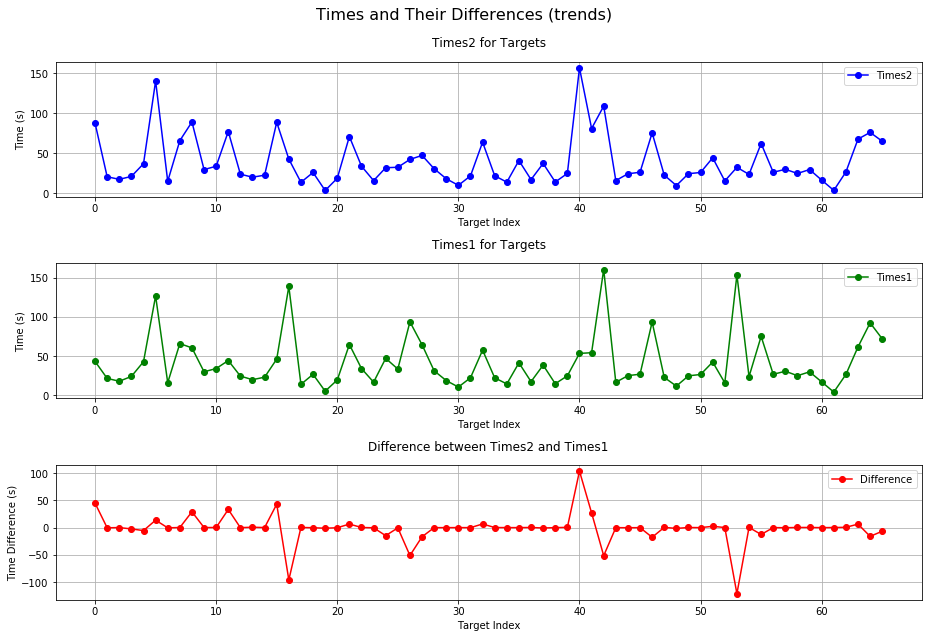

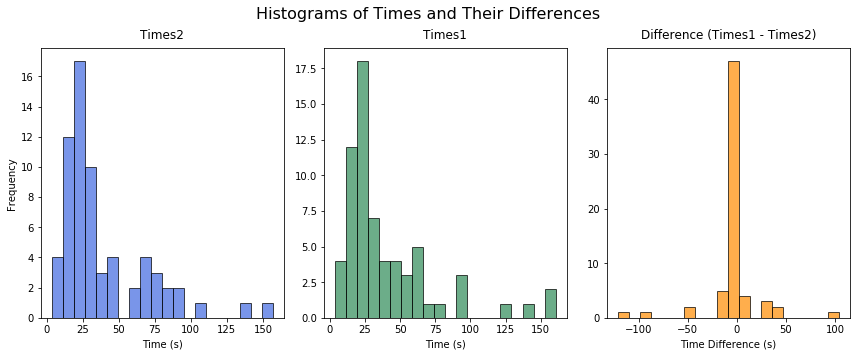

In [174]:

plt.close('all') 
fig, ax = plt.subplots(3,1, figsize=(13, 9)) 

# # Subplot 1: Times2
ax[0].set_title('Times2 for Targets', pad=15)
ax[0].plot(times2, marker='o', linestyle='-', color='b', label='Times2')
ax[0].set_xlabel('Target Index')
ax[0].set_ylabel('Time (s)')
ax[0].legend()
ax[0].grid()

# Subplot 2: Times1
ax[1].set_title('Times1 for Targets', pad=15)
ax[1].plot(times1, marker='o', linestyle='-', color='g', label='Times1')
ax[1].set_xlabel('Target Index')
ax[1].set_ylabel('Time (s)')
ax[1].legend()
ax[1].grid()

# Subplot 3: Difference
ax[2].set_title('Difference between Times2 and Times1', pad=15)
ax[2].plot(diff_f, marker='o', linestyle='-', color='r', label='Difference')
ax[2].set_xlabel('Target Index')
ax[2].set_ylabel('Time Difference (s)')
ax[2].legend()
ax[2].grid()
# Titolo generale
fig.suptitle('Times and Their Differences (trends)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Trends.png')
plt.show()
# ###########################################
fig2, ax2 = plt.subplots(1,3, figsize=(12, 5))
# Histogram of Times2
ax2[0].hist(times2, bins=20, color='royalblue', alpha=0.7, edgecolor='black')
ax2[0].set_title('Times2', pad=10)
ax2[0].set_xlabel('Time (s)')
ax2[0].set_ylabel('Frequency')

#2 2Histogram of Times1
ax2[1].hist(times1, bins=20, color='seagreen', alpha=0.7, edgecolor='black')
ax2[1].set_title('Times1', pad=10)
ax2[1].set_xlabel('Time (s)')

#2 2Histogram of Difference
ax2[2].hist(diff_f, bins=20, color='darkorange', alpha=0.7, edgecolor='black')
ax2[2].set_title('Difference (Times1 - Times2)', pad=10)
ax2[2].set_xlabel('Time Difference (s)')

# Titolo generale
fig2.suptitle('Histograms of Times and Their Differences', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('improved_histograms.png')
plt.show()


Comuputation of the Wilcoxon signed test   
hp:  
    - indipendence of the elements  
    - ordered

In [175]:
# # paired Wilcoxon test
diff_nonzero = diff_f[diff_f != 0]

# obtain the ranks of the absolute values of the differences
diff_abs = np.abs(diff_nonzero)

# occurrencies
unique_vals, counts = np.unique(diff_abs, return_counts=True)

# ranks
current_rank = 1
rank_dict = {}
for val, count in zip(unique_vals, counts):
    if count == 1:
        avg_rank = current_rank
    else:
        avg_rank = (current_rank + current_rank + count - 1) / 2
    rank_dict[val] = avg_rank
    current_rank += count

# assign th ranks
ranks = np.array([rank_dict[val] for val in diff_abs])

# assign signs 
signs = np.sign(diff_nonzero)
ranks_signed = ranks * signs

# calculation of W+ e W-
W_pos = np.sum(ranks_signed[ranks_signed > 0])
W_neg = -np.sum(ranks_signed[ranks_signed < 0])

# W value
W = min(W_pos, W_neg)

# z value as the number of targets is grater than 30
n = len(diff_nonzero)
z = (W-(n*(n+1)/4))/np.sqrt((n*(n+1)*(2*n+1))/24)

print(f"W+ = {W_pos}, W- = {W_neg}, Test statistic W = {W}")
print(f"x_medio = {n*(n+1)/4}")
print(f"Deviazione standard = {np.sqrt((n*(n+1)*(2*n+1))/24)}")
print(f"Z statstico= {z}")


W+ = 1073.0, W- = 1138.0, Test statistic W = 1073.0
x_medio = 1105.5
Deviazione standard = 156.5415280364926
Z statstico= -0.2076126406050136
